# ISMIP7 Ocean Temperature Check

Autogenerated inspection notebook for `output/ismip7_thetao_point_subset.nc`.


In [1]:
from __future__ import annotations

import json
from datetime import datetime, timedelta
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt


DATA_PATH = Path('output/ismip7_thetao_point_subset.nc')

plt.rcParams.update(
    {
        "figure.figsize": (10, 5.5),
        "figure.dpi": 130,
        "savefig.dpi": 180,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.facecolor": "#f8f7f4",
        "grid.alpha": 0.3,
        "font.size": 11,
    }
)


def _decode(value):
    if isinstance(value, bytes):
        return value.decode("utf-8")
    if isinstance(value, np.ndarray) and value.shape == (1,):
        return _decode(value[0])
    return value


def _parse_time_axis(time_values, time_units):
    if not time_units or not str(time_units).startswith("days since "):
        return np.asarray(time_values), "time"
    base = datetime.fromisoformat(str(time_units).replace("days since ", "").strip())
    dt = np.array([base + timedelta(days=float(day)) for day in time_values], dtype=object)
    return dt, "time"


with h5py.File(DATA_PATH, "r") as ds:
    keys = list(ds.keys())
    coord_like = {
        "point",
        "point_name",
        "time",
        "z",
        "sample_name",
        "requested_latitude",
        "requested_longitude",
        "requested_x",
        "requested_y",
        "latitude",
        "longitude",
        "x",
        "y",
    }
    data_var_name = next(name for name in keys if name not in coord_like and ds[name].ndim >= 2)
    data = ds[data_var_name][:]
    point_names = [_decode(v) for v in ds["point_name"][:]]
    attrs = {k: _decode(v) for k, v in ds.attrs.items()}
    var_attrs = {k: _decode(v) for k, v in ds[data_var_name].attrs.items()}
    requested_latitude = ds["requested_latitude"][:]
    requested_longitude = ds["requested_longitude"][:]
    actual_latitude = ds["latitude"][:]
    actual_longitude = ds["longitude"][:]

    has_time = "time" in ds and data.ndim == 2 and ds["time"].shape[0] == data.shape[0]
    has_sample = "sample_name" in ds
    has_z = "z" in ds and ((data.ndim == 2 and ds["z"].shape[0] == data.shape[0]) or (data.ndim == 3 and ds["z"].shape[0] == data.shape[1]))

    if has_time:
        time_values = ds["time"][:]
        time_units = _decode(ds["time"].attrs.get("units"))
        time_axis, x_label = _parse_time_axis(time_values, time_units)
    else:
        time_axis = None
        x_label = None

    if has_sample:
        sample_names = [_decode(v) for v in ds["sample_name"][:]]
    else:
        sample_names = None

    if has_z:
        z = ds["z"][:]
        z_attrs = {k: _decode(v) for k, v in ds["z"].attrs.items()}
    else:
        z = None
        z_attrs = {}

print("data variable:", data_var_name)
print("shape:", data.shape)
print("points:", point_names)
print("global attrs subset_source_files:", attrs.get("subset_source_files"))
print("var attrs:", var_attrs)
if has_time:
    print("time span:", time_axis[0], "to", time_axis[-1])
if has_sample:
    print("sample labels:", sample_names)
if has_z:
    print("z range:", float(np.min(z)), "to", float(np.max(z)))


data variable: thetao
shape: (3, 30, 6)
points: ['Ross J9', 'Amery G1', 'PIG', 'Larsen C', 'Thwaites', 'Ronne']
global attrs subset_source_files: ["thetao_Oyr_CESM2-WACCM_ssp585_r1i1p1f1_ismip8km_60m_2079-2099.nc", "thetao_Oyr_CESM2-WACCM_ssp585_r1i1p1f1_ismip8km_60m_2179-2199.nc", "thetao_Oyr_CESM2-WACCM_ssp585_r1i1p1f1_ismip8km_60m_2279-2299.nc"]
var attrs: {'DIMENSION_LIST': array([array([<HDF5 object reference>], dtype=object),
       array([<HDF5 object reference>], dtype=object),
       array([<HDF5 object reference>], dtype=object)], dtype=object), '_Netcdf4Coordinates': array([0, 2, 1], dtype=int32), '_Netcdf4Dimid': 0, 'coordinates': 'lat lon'}
sample labels: ['2079-2099', '2179-2199', '2279-2299']
z range: -1770.0 to -30.0


In [2]:
print("Coordinate check:")
for i, name in enumerate(point_names):
    print(f"\n{name}")
    print(f"  requested lat/lon: {requested_latitude[i]:.6f}, {requested_longitude[i]:.6f}")
    print(f"  matched   lat/lon: {actual_latitude[i]:.6f}, {actual_longitude[i]:.6f}")


Coordinate check:

Ross J9
  requested lat/lon: -82.375000, -168.626000
  matched   lat/lon: -82.357697, -168.906277

Amery G1
  requested lat/lon: -69.451000, 71.497000
  matched   lat/lon: -69.490566, 71.565051

PIG
  requested lat/lon: -75.100000, -100.500000
  matched   lat/lon: -75.105331, -100.481218

Larsen C
  requested lat/lon: -68.008600, -64.367500
  matched   lat/lon: -67.969329, -64.365818

Thwaites
  requested lat/lon: -75.100000, -105.750000
  matched   lat/lon: -75.092515, -105.674770

Ronne
  requested lat/lon: -79.500000, -58.000000
  matched   lat/lon: -79.507492, -57.867104


In [3]:
if has_time:
    fig, ax = plt.subplots(figsize=(12, 6))
    for i, name in enumerate(point_names):
        ax.plot(time_axis, data[:, i], linewidth=1.6, label=name)
    ax.set_title(f"{data_var_name} point time series")
    ax.set_xlabel(x_label)
    ax.set_ylabel(var_attrs.get("units", data_var_name))
    ax.grid(True, axis="y")
    ax.legend(frameon=False, ncol=2)
    fig.autofmt_xdate()
    plt.show()
else:
    print("Time-series plot skipped: no time axis detected.")


Time-series plot skipped: no time axis detected.


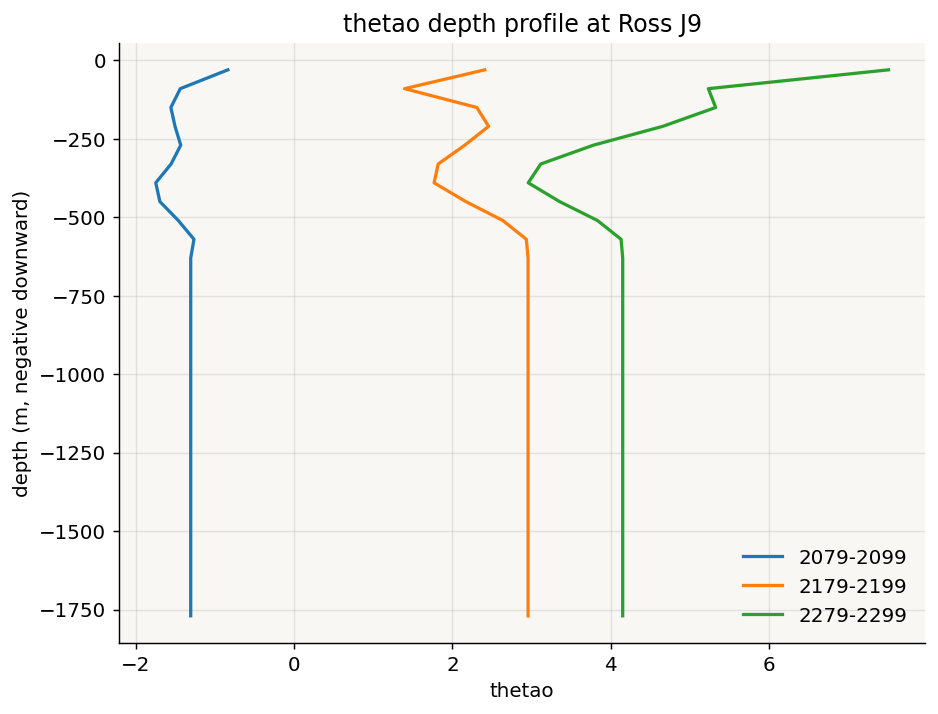

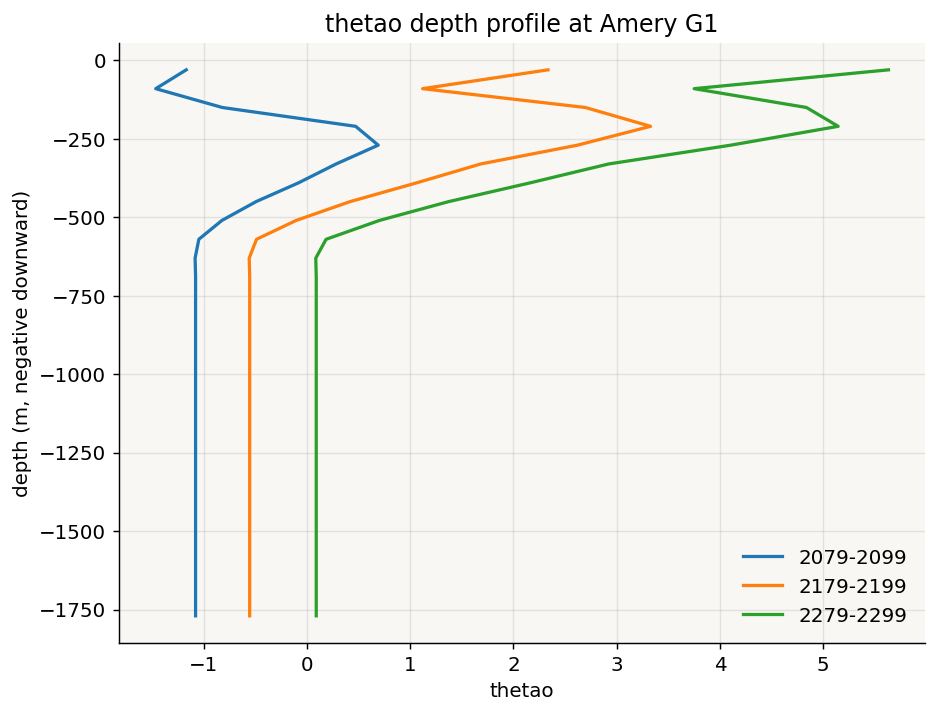

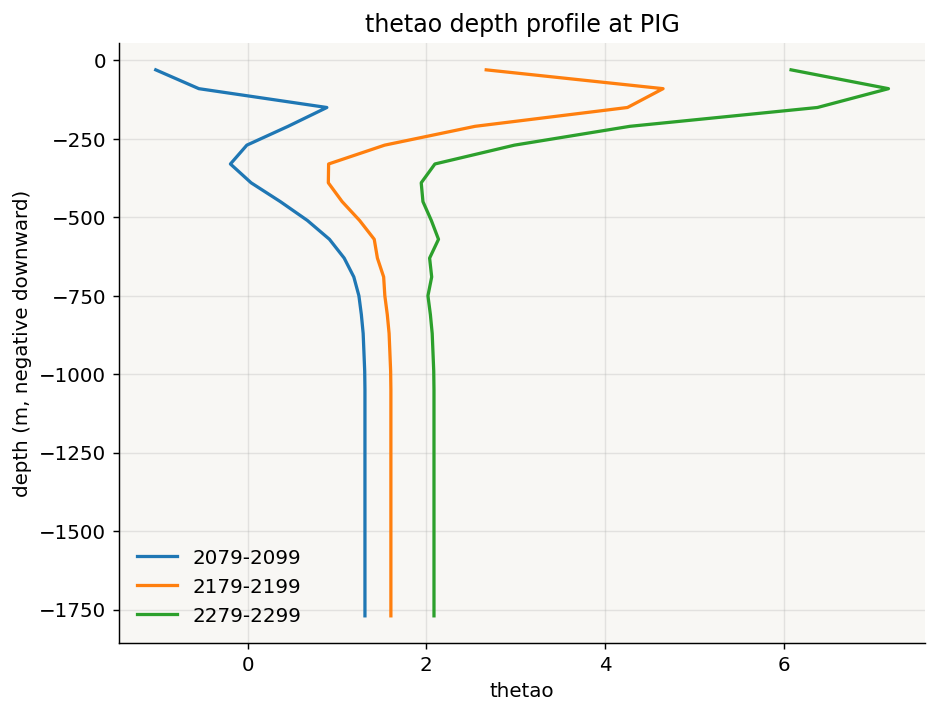

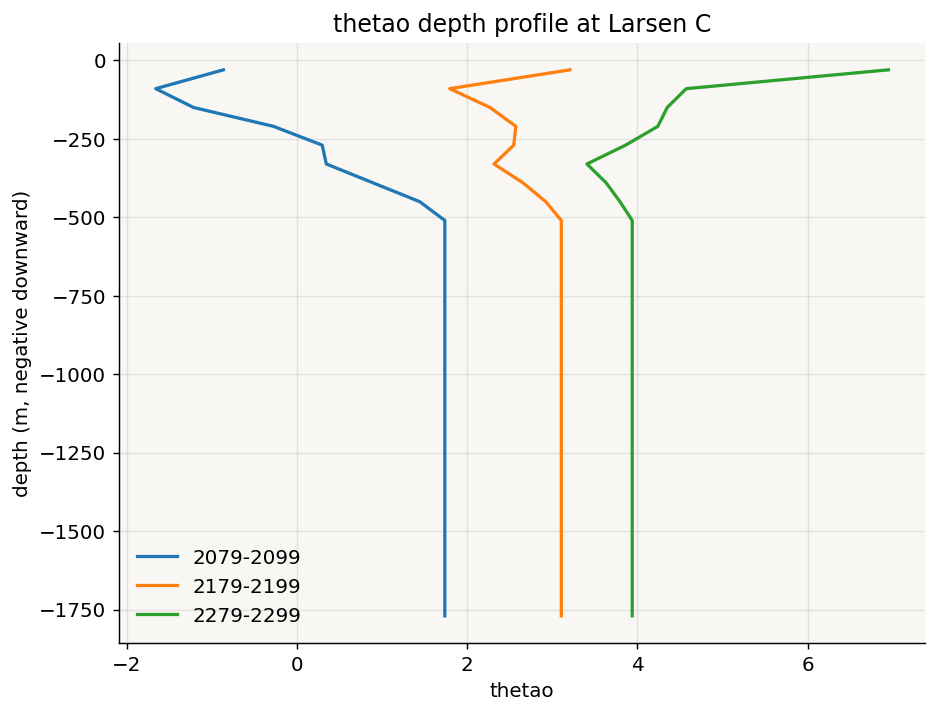

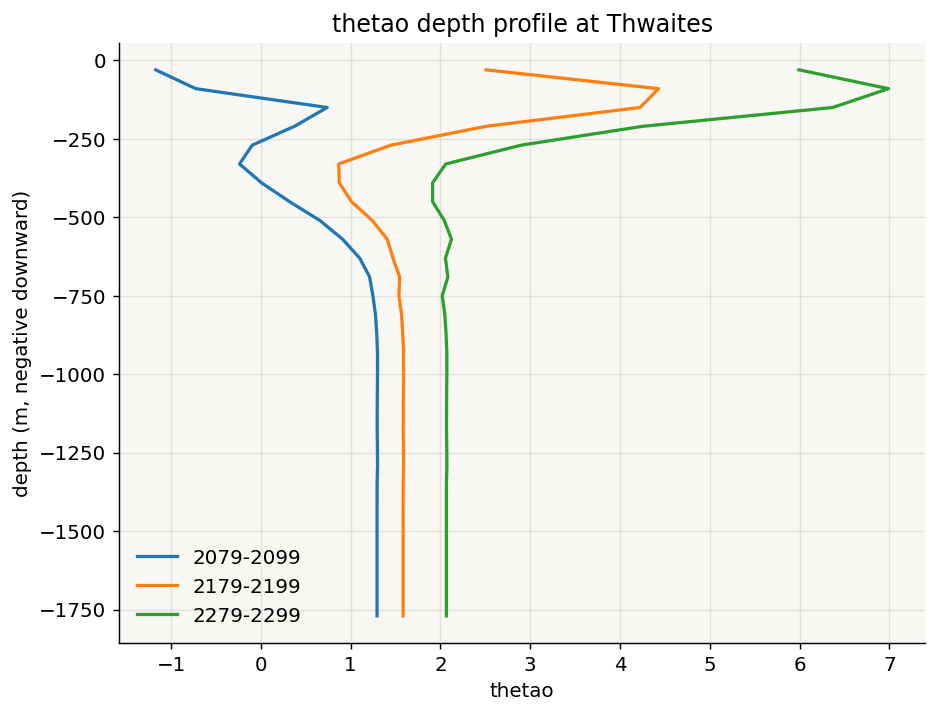

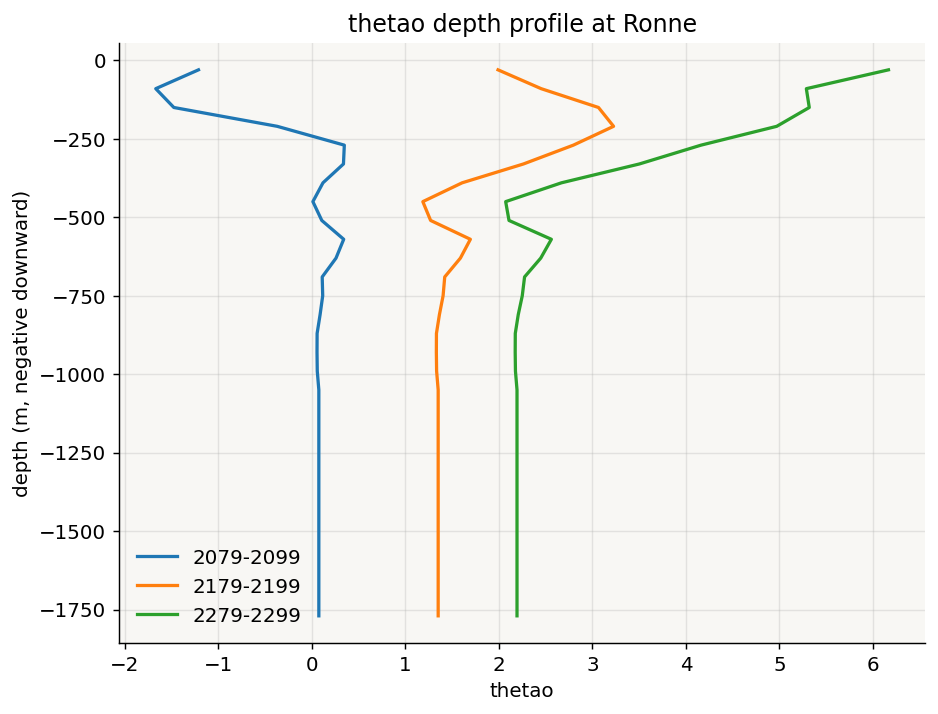

In [4]:
if has_sample and has_z and data.ndim == 3:
    for point_index, point_name in enumerate(point_names):
        fig, ax = plt.subplots(figsize=(8, 6))
        for sample_index, sample_name in enumerate(sample_names):
            ax.plot(data[sample_index, :, point_index], z, linewidth=1.8, label=sample_name)
        ax.set_title(f"{data_var_name} depth profile at {point_name}")
        ax.set_xlabel(var_attrs.get("units", data_var_name))
        ax.set_ylabel("depth (m, negative downward)")
        ax.grid(True)
        ax.legend(frameon=False)
        plt.show()
elif has_sample and data.ndim == 2:
    fig, ax = plt.subplots(figsize=(12, 5))
    for point_index, point_name in enumerate(point_names):
        ax.plot(sample_names, data[:, point_index], marker="o", linewidth=1.8, label=point_name)
    ax.set_title(f"{data_var_name} by sample")
    ax.set_xlabel("sample")
    ax.set_ylabel(var_attrs.get("units", data_var_name))
    ax.grid(True, axis="y")
    ax.legend(frameon=False, ncol=2)
    ax.tick_params(axis="x", rotation=25)
    plt.show()
else:
    print("Sample/profile plot skipped: incompatible dimensions.")


In [5]:
summary = {
    "data_var_name": data_var_name,
    "shape": list(data.shape),
    "point_names": point_names,
    "min": float(np.nanmin(data)),
    "max": float(np.nanmax(data)),
    "mean_by_point": {name: float(np.nanmean(data[..., i])) for i, name in enumerate(point_names)},
}
summary


{'data_var_name': 'thetao',
 'shape': [3, 30, 6],
 'point_names': ['Ross J9',
  'Amery G1',
  'PIG',
  'Larsen C',
  'Thwaites',
  'Ronne'],
 'min': -1.7457168102264404,
 'max': 7.505082607269287,
 'mean_by_point': {'Ross J9': 1.860782641172409,
  'Amery G1': 0.113030770007107,
  'PIG': 1.7644384084890286,
  'Larsen C': 2.7475658585627873,
  'Thwaites': 1.7354649592915343,
  'Ronne': 1.4476238321616417}}